# ArchitectAgent Fine-Tuning Pipeline
## QLoRA Training of Phi-3-mini-128k-instruct for Architecture Plan Generation

**Task:** Train a specialised ArchitectAgent that produces structured JSON architecture plans  
**Method:** QLoRA (4-bit NormalFloat quantisation) with completion-only loss masking  
**Base Model:** Microsoft Phi-3-mini-128k-instruct (3.8B parameters)

---

### Key Design Decisions

| Decision | Choice | Justification |
|----------|--------|---------------|
| Base model | Phi-3-mini-128k-instruct | 3.8B params fits in 16GB VRAM with QLoRA; 128K context window far exceeds our max of 16000 tokens |
| Fine-tuning method | QLoRA (LoRA rank=64, all linear layers) | Trains only ~1.7% of parameters; 4-bit NF4 reduces memory from ~7.6GB to ~2GB |
| Loss masking | DataCollatorForCompletionOnlyLM | Ensures loss is computed ONLY on the assistant output (plan JSON). Without this, the model exploits the repetitive input contract instead of learning to generate plans |
| Data split | Chain-aware 85/15 | All rounds of the same planning chain stay in the same split, preventing leakage of the same project goal across train/val |
| Epochs | 5 | Standard convergence point for ~800 rows; eval loss plateaus at this point |
| max_seq_length | 16896 | Dataset analysis shows 100% of rows fit within 16896 tokens (max total = 16000) |
| max_new_tokens | 6144 | Largest output in dataset is 6000 tokens; 6144 gives a 35-token safety margin |

---
## Section 1 — Environment Setup

In [1]:
import os, json, time, hashlib, warnings, random, re, copy
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoConfig,
    BitsAndBytesConfig, TrainingArguments, TrainerCallback,
)
from peft import (
    LoraConfig, get_peft_model, prepare_model_for_kbit_training,
    PeftModel, TaskType,
)
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
from datasets import Dataset
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected')
print(f'Seed: {SEED}')

PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition
VRAM: 102.0 GB
Seed: 42


In [2]:
DATASET_PATH = 'architect_dataset_final.jsonl'
MODEL_NAME = 'microsoft/Phi-3-mini-128k-instruct'

OUTPUT_DIR = Path('training_output')
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)
FINAL_MODEL_DIR = OUTPUT_DIR / 'architect_agent_model'
FINAL_MODEL_DIR.mkdir(exist_ok=True)
LOGS_DIR = OUTPUT_DIR / 'logs'
LOGS_DIR.mkdir(exist_ok=True)

CONFIG = {
    'lora_r': 64,
    'lora_alpha': 128,
    'lora_dropout': 0.05,
    'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    'num_epochs': 5,
    'per_device_batch_size': 1,
    'gradient_accumulation': 8,
    'learning_rate': 1e-4,
    'lr_scheduler': 'cosine',
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0,
    'max_seq_length': 16896,
    'max_new_tokens': 6144,
    'val_ratio': 0.15,
}

for k, v in CONFIG.items():
    print(f'  {k}: {v}')

  lora_r: 64
  lora_alpha: 128
  lora_dropout: 0.05
  target_modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
  num_epochs: 5
  per_device_batch_size: 1
  gradient_accumulation: 8
  learning_rate: 0.0001
  lr_scheduler: cosine
  warmup_ratio: 0.1
  weight_decay: 0.01
  max_grad_norm: 1.0
  max_seq_length: 16896
  max_new_tokens: 6144
  val_ratio: 0.15


---
## Section 2 — System Prompt & Data Loading

The system prompt is identical to `main.py` AGENT_PROMPTS["ArchitectAgent"] + GLOBAL_SYSTEM.
This ensures the fine-tuned model produces output in the exact format `normalize_plan()` expects at runtime.

In [3]:
ARCHITECT_SYSTEM_PROMPT = """You are part of an advanced architectural governance terminal application.

Core rules:
1. Never rely only on chat history for important facts; use structured memory.
2. Requirement gathering is collaborative and user-facing.
3. Planning and auditing are mostly internal.
4. The final plan must be implementation-grade and security-aware.
5. The architect must revise using cumulative issue memory, not forget earlier feedback.
6. The auditor must use stable issue IDs and mark issues as resolved, unresolved, downgraded, or newly introduced.
7. Visible reasoning must be concise summarized reasoning, not hidden chain-of-thought.
8. Mandatory requirement blockers are dynamic. A small core is always required, and additional required fields depend on project_class, capabilities, risk_level, data_sensitivity, and external_exposure.
9. Never advance to planning until all active required fields are populated and confirmed.
10. Once planning starts, keep round-by-round turbulence internal unless the entire planning attempt fails.

You are the architecture generator.

Create a polished implementation-grade architecture plan from:
- frozen confirmed requirement contract
- rich requirement notes
- specialist reviews
- cumulative issue ledger
- focus issues
- revision memory
- previous audits
- best prior plan

Main goal:
- First, address the current focus issues.
- Second, preserve all user-confirmed requirements.
- Third, improve the architecture without introducing regressions.

Rules:
- Do not mention round numbers in the title.
- Preserve user-confirmed requirements.
- Prioritize unresolved critical and high-severity focus issues first.
- For each focus issue, either fix it in the plan or clearly explain why it remains unresolved.
- Do not ignore recurring unresolved issues from previous rounds.
- Try to improve weak areas identified by the auditor before adding extra design complexity.
- Include concrete architecture, modules, workflows, schemas, APIs, security, deployment, observability, roadmap, and developer guidance.
- Keep the plan implementation-grade and specific, not generic.

Return JSON only with:
- thinking_summary
- fix_report
- title
- executive_summary
- architecture_overview
- technology_stack
- functional_feature_map
- system_components
- workflows
- data_model
- api_design
- security_and_compliance
- deployment_and_operations
- observability
- cost_and_scaling
- phased_implementation
- development_guidelines
- risks_and_tradeoffs
- open_questions_resolved

fix_report must be a list of items with:
- issue_id
- action_taken
- changed_sections
- expected_outcome

For each fix_report item:
- issue_id must match the issue being addressed
- action_taken must say what was changed
- changed_sections must name the plan sections updated
- expected_outcome must explain what the auditor should now find improved"""

print(f'system prompt: {len(ARCHITECT_SYSTEM_PROMPT)} characters')

system prompt: 2856 characters


In [4]:
def load_jsonl(filepath):
    rows = []
    errors = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    errors += 1
    return rows, errors


raw_data, load_errors = load_jsonl(DATASET_PATH)
print(f'loaded {len(raw_data)} rows, {load_errors} skipped')

case_types = Counter(r.get('metadata', {}).get('case_type', '?') for r in raw_data)
plan_quality = Counter(r.get('metadata', {}).get('plan_quality', '?') for r in raw_data)

# project_class handles both snake_case and compact forms from the dataset
pclasses = Counter(
    r.get('profile', {}).get('project_class', '') or r.get('profile', {}).get('projectclass', '?')
    for r in raw_data
)

print(f'case types: {dict(case_types)}')
print(f'plan quality: {dict(plan_quality)}')
print(f'project classes ({len(pclasses)}): {dict(pclasses)}')

loaded 891 rows, 0 skipped
case types: {'revision_round': 536, 'first_pass': 355}
plan quality: {'low': 135, 'moderate': 315, 'good': 441}
project classes (14): {'desktop_app': 62, 'library_sdk': 64, 'mobile_app': 65, 'api_service': 64, 'infrastructure_project': 64, 'web_app': 64, 'landing_page': 64, 'research_prototype': 64, 'data_pipeline': 64, 'fullstack_app': 65, 'ai_system': 63, 'automation_tool': 64, 'cli_tool': 63, 'static_website': 61}


---
## Section 3 — Tokenizer & Data Formatting

Each training example is formatted as a complete chat text using Phi-3's chat template.
`DataCollatorForCompletionOnlyLM` then masks all input tokens so loss is computed only on the plan JSON.

The input to the model mirrors the exact payload that `main.py` `architect_generate()` sends at runtime:
`round`, `frozen_requirement_contract`, `requirements`, `reasoner_reviews`, `specialist_subplans`,
`issue_ledger`, `focus_issues`, `revision_memory`, `accepted_exceptions`, `previous_audits`,
`previous_plan`, `best_plan`.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'tokenizer: {MODEL_NAME}')
print(f'vocab: {tokenizer.vocab_size}, pad: {tokenizer.pad_token}, eos: {tokenizer.eos_token}')

tokenizer: microsoft/Phi-3-mini-128k-instruct
vocab: 32000, pad: <|endoftext|>, eos: <|endoftext|>


In [6]:
def get_nested(d, *keys, default=None):
    for k in keys:
        if isinstance(d, dict) and k in d:
            return d[k]
    return default


def format_row_as_text(row):
    payload = row.get('input_payload', {})
    target = row.get('target_output', {})

    # Mirror the exact payload structure of main.py architect_generate()
    architect_input = {
        'round': payload.get('round', 1),
        'frozen_requirement_contract': get_nested(
            payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        ),
        'requirements': payload.get('requirements', {}),
        'reasoner_reviews': get_nested(
            payload, 'reasoner_reviews', 'reasonerreviews', default={}
        ),
        'specialist_subplans': get_nested(
            payload, 'specialist_subplans', 'specialistsubplans', default={}
        ),
        'issue_ledger': get_nested(
            payload, 'issue_ledger', 'issueledger', default={}
        ),
        'focus_issues': get_nested(
            payload, 'focus_issues', 'focusissues', default=[]
        ),
        'revision_memory': get_nested(
            payload, 'revision_memory', 'revisionmemory', default={}
        ),
        'accepted_exceptions': get_nested(
            payload, 'accepted_exceptions', 'acceptedexceptions', default={}
        ),
        'previous_audits': get_nested(
            payload, 'previous_audits', 'previousaudits', default=[]
        ),
        'previous_plan': get_nested(
            payload, 'previous_plan', 'previousplan', default={}
        ),
        'best_plan': get_nested(
            payload, 'best_plan', 'bestplan', default={}
        ),
    }

    messages = [
        {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(architect_input, indent=1, ensure_ascii=False)},
        {'role': 'assistant', 'content': json.dumps(target, indent=1, ensure_ascii=False)},
    ]

    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)


formatted_texts = []
chain_fps = []
sample_ids = []
token_counts = []
skipped = 0

for row in raw_data:
    try:
        text = format_row_as_text(row)
        n_tokens = len(tokenizer.encode(text, add_special_tokens=False))
        if n_tokens > CONFIG['max_seq_length']:
            skipped += 1
            continue
        formatted_texts.append(text)
        token_counts.append(n_tokens)
        sample_ids.append(row.get('sample_id', ''))

        contract = get_nested(
            row.get('input_payload', {}),
            'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        )
        fp = hashlib.sha256(json.dumps(contract, sort_keys=True).encode()).hexdigest()[:16]
        chain_fps.append(fp)
    except Exception as e:
        skipped += 1

print(f'formatted: {len(formatted_texts)} rows')
print(f'skipped (too long / error): {skipped}')
print(f'token counts: mean={np.mean(token_counts):.0f}, median={np.median(token_counts):.0f}, max={max(token_counts)}')

# Format verification
print(f'\n{"="*60}')
print('FORMAT VERIFICATION')
print(f'{"="*60}')

sample = formatted_texts[0]
assistant_marker = '<|assistant|>'

if assistant_marker in sample:
    pos = sample.index(assistant_marker)
    total_chars = len(sample)
    print(f'  assistant marker at position {pos}')
    print(f'  input: {pos} chars ({pos/total_chars*100:.0f}%), output: {total_chars-pos} chars ({(total_chars-pos)/total_chars*100:.0f}%)')

    assistant_text = sample[pos:]
    expected_keys = [
        'thinking_summary', 'fix_report', 'title', 'executive_summary',
        'architecture_overview', 'technology_stack', 'security_and_compliance',
        'deployment_and_operations', 'risks_and_tradeoffs', 'open_questions_resolved'
    ]
    found = [k for k in expected_keys if k in assistant_text]
    missing = [k for k in expected_keys if k not in assistant_text]
    print(f'\n  expected keys found: {found}')
    if missing:
        print(f'  WARNING missing keys: {missing}')
    else:
        print(f'  all expected keys present')
else:
    print('  CRITICAL: <|assistant|> marker not found — chat template not working')

formatted: 891 rows
skipped (too long / error): 0
token counts: mean=10106, median=10081, max=16861

FORMAT VERIFICATION
  assistant marker at position 19429
  input: 19429 chars (67%), output: 9543 chars (33%)

  expected keys found: ['thinking_summary', 'fix_report', 'title', 'executive_summary', 'architecture_overview', 'technology_stack', 'security_and_compliance', 'deployment_and_operations', 'risks_and_tradeoffs', 'open_questions_resolved']
  all expected keys present


---
## Section 4 — Completion-Only Loss Masking

`DataCollatorForCompletionOnlyLM` masks all tokens before the assistant turn.
Without this, the model achieves low loss by predicting the repetitive frozen contract
instead of learning to generate 19-section architecture plans.

From the dataset analysis, input tokens are ~61% of total (mean 2228 input / 3670 total).
Expected masking ratio: ~60-65% masked, ~35-40% unmasked.

In [7]:
response_template = '<|assistant|>'
response_template_ids = tokenizer.encode(response_template, add_special_tokens=False)

print(f'response template: \'{response_template}\'')
print(f'template token IDs: {response_template_ids}')

collator = DataCollatorForCompletionOnlyLM(
    response_template=response_template_ids,
    tokenizer=tokenizer,
)

print(f'\n{"="*60}')
print('LOSS MASKING VERIFICATION')
print(f'{"="*60}')

for i in range(min(5, len(formatted_texts))):
    enc = tokenizer(
        formatted_texts[i], return_tensors='pt',
        truncation=True, max_length=CONFIG['max_seq_length']
    )
    batch = collator([{
        'input_ids': enc['input_ids'][0],
        'attention_mask': enc['attention_mask'][0]
    }])
    labels = batch['labels'][0]
    masked = (labels == -100).sum().item()
    unmasked = (labels != -100).sum().item()
    total = len(labels)
    print(f'  example {i}: {total} tokens, masked={masked} ({masked/total*100:.0f}%), unmasked={unmasked} ({unmasked/total*100:.0f}%)')

avg_unmasked_pct = []
for i in range(min(20, len(formatted_texts))):
    enc = tokenizer(
        formatted_texts[i], return_tensors='pt',
        truncation=True, max_length=CONFIG['max_seq_length']
    )
    batch = collator([{
        'input_ids': enc['input_ids'][0],
        'attention_mask': enc['attention_mask'][0]
    }])
    labels = batch['labels'][0]
    total = len(labels)
    unmasked = (labels != -100).sum().item()
    avg_unmasked_pct.append(unmasked / total * 100)

mean_pct = np.mean(avg_unmasked_pct)
print(f'\n  average unmasked: {mean_pct:.1f}%')
if mean_pct < 5:
    print('  CRITICAL: less than 5% unmasked — masking may be broken')
elif mean_pct > 60:
    print('  WARNING: more than 60% unmasked — check template detection')
else:
    print(f'  good: ~{mean_pct:.0f}% of tokens are plan output (loss computed on these)')

response template: '<|assistant|>'
template token IDs: [32001]

LOSS MASKING VERIFICATION
  example 0: 8939 tokens, masked=6327 (71%), unmasked=2612 (29%)
  example 1: 11188 tokens, masked=7833 (70%), unmasked=3355 (30%)
  example 2: 9089 tokens, masked=5902 (65%), unmasked=3187 (35%)
  example 3: 11916 tokens, masked=8358 (70%), unmasked=3558 (30%)
  example 4: 10731 tokens, masked=6695 (62%), unmasked=4036 (38%)

  average unmasked: 35.5%
  good: ~35% of tokens are plan output (loss computed on these)


---
## Section 5 — Chain-Aware Train/Validation Split

All rounds of the same planning chain (same frozen contract) stay in the same split.
This prevents the model from seeing round-1 of a project in training and round-2 in validation.

In [8]:
chains = defaultdict(list)
for i, fp in enumerate(chain_fps):
    chains[fp].append(i)

chain_ids = list(chains.keys())
rng = random.Random(SEED)
rng.shuffle(chain_ids)

n_val = max(1, int(len(chain_ids) * CONFIG['val_ratio']))
val_chain_set = set(chain_ids[:n_val])

train_idx, val_idx = [], []
for cid in chain_ids:
    target = val_idx if cid in val_chain_set else train_idx
    target.extend(chains[cid])

train_texts = [formatted_texts[i] for i in train_idx]
val_texts = [formatted_texts[i] for i in val_idx]

train_dataset = Dataset.from_dict({'text': train_texts})
val_dataset = Dataset.from_dict({'text': val_texts})

train_chains = set(chain_fps[i] for i in train_idx)
val_chains = set(chain_fps[i] for i in val_idx)
leakage = train_chains & val_chains

print(f'chains: {len(chains)} total, {len(chains) - n_val} train, {n_val} val')
print(f'rows: {len(train_texts)} train, {len(val_texts)} val')
print(f'chain leakage: {"none" if not leakage else f"DETECTED: {len(leakage)} chains"}')

# Case type distribution in each split
train_sids = set(sample_ids[i] for i in train_idx)
val_sids = set(sample_ids[i] for i in val_idx)
train_rows = [r for r in raw_data if r.get('sample_id', '') in train_sids]
val_rows = [r for r in raw_data if r.get('sample_id', '') in val_sids]

train_ct = Counter(r.get('metadata', {}).get('case_type', '') for r in train_rows)
val_ct = Counter(r.get('metadata', {}).get('case_type', '') for r in val_rows)
print(f'train case types: {dict(train_ct)}')
print(f'val case types:   {dict(val_ct)}')

chains: 891 total, 758 train, 133 val
rows: 758 train, 133 val
chain leakage: none
train case types: {'revision_round': 452, 'first_pass': 306}
val case types:   {'revision_round': 84, 'first_pass': 49}


---
## Section 6 — Model Loading with 4-bit Quantisation

NF4 quantisation reduces the 3.8B model from ~7.6GB to ~2GB,
enabling training on 16GB VRAM GPUs.

In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)

print(f'loading {MODEL_NAME}...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=False,
    attn_implementation='sdpa',
    torch_dtype=torch.bfloat16,
)

model.config.use_cache = True
model.config.pretraining_tp = 1
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

total_params = sum(p.numel() for p in model.parameters())
print(f'model loaded: {total_params:,} parameters')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB')

`torch_dtype` is deprecated! Use `dtype` instead!


loading microsoft/Phi-3-mini-128k-instruct...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

model loaded: 2,009,140,224 parameters
GPU memory: 2.66 GB


---
## Section 7 — LoRA Adapter Configuration

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Rank (r) | 64 | Higher rank needed because the output is 19 structured sections with specific key names, JSON structure, and domain-specific content across all of them |
| Alpha | 128 | Standard 2r ratio for stable gradient scaling |
| Dropout | 0.05 | Light regularisation; ~800 rows is small but the structured JSON task is well-defined |
| Target modules | All 7 linear layers | Full coverage needed because the task requires learning both JSON format and architectural domain knowledge simultaneously |

In [10]:
lora_config = LoraConfig(
    r=CONFIG['lora_r'],
    lora_alpha=CONFIG['lora_alpha'],
    lora_dropout=CONFIG['lora_dropout'],
    target_modules=CONFIG['target_modules'],
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
pct = trainable / total * 100

print(f'trainable: {trainable:,} / {total:,} ({pct:.2f}%)')
model.print_trainable_parameters()

trainable: 35,651,584 / 2,044,791,808 (1.74%)
trainable params: 35,651,584 || all params: 3,856,731,136 || trainable%: 0.9244


---
## Section 8 — Training Configuration & Execution

Initial training loss will be higher than a full-sequence run (expected ~1.5-3.0)
because loss is computed only on the assistant plan JSON, not the input payload.
This is correct — the model is learning the hard part.

In [11]:
total_steps = len(train_dataset) * CONFIG['num_epochs'] // CONFIG['gradient_accumulation']
eval_steps = max(1, int(total_steps * 0.1))
save_steps = eval_steps * 3

print(f'training plan:')
print(f'  examples: {len(train_dataset)} train, {len(val_dataset)} val')
print(f'  epochs: {CONFIG["num_epochs"]}, effective batch: {CONFIG["gradient_accumulation"]}')
print(f'  steps: ~{total_steps}, eval every {eval_steps}, save every {save_steps}')

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=CONFIG["gradient_accumulation"],
    learning_rate=CONFIG["learning_rate"],
    lr_scheduler_type=CONFIG["lr_scheduler"],
    warmup_ratio=CONFIG["warmup_ratio"],
    weight_decay=CONFIG["weight_decay"],
    max_grad_norm=CONFIG["max_grad_norm"],
    bf16=True,
    fp16=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=save_steps,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=5,
    save_total_limit=3,
    report_to="tensorboard",
    seed=SEED,
)
print('training args ready')

training plan:
  examples: 758 train, 133 val
  epochs: 5, effective batch: 8
  steps: ~473, eval every 47, save every 141
training args ready


In [12]:
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.learning_rates = []
        self.steps = []
        self.eval_steps_list = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
                self.steps.append(state.global_step)
            if 'learning_rate' in logs:
                self.learning_rates.append(logs['learning_rate'])
            if 'eval_loss' in logs:
                self.eval_losses.append(logs['eval_loss'])
                self.eval_steps_list.append(state.global_step)


metrics_cb = MetricsCallback()

In [13]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=collator,
    max_seq_length=CONFIG['max_seq_length'],
    dataset_text_field='text',
    packing=False,
    callbacks=[metrics_cb],
)

torch.cuda.empty_cache()
print(f'free VRAM before training: {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved, 'f'{torch.cuda.mem_get_info(0)[0]/1e9:.1f} GB free')

print('starting training with completion-only loss masking...')
print('=' * 60)

start_time = time.time()
train_result = trainer.train()
elapsed = time.time() - start_time

print('=' * 60)
print('TRAINING COMPLETE')
print(f'  duration: {elapsed/60:.1f} minutes')
print(f'  final loss: {train_result.training_loss:.4f}')
print(f'  steps: {train_result.global_step}')

trainer.save_metrics('train', train_result.metrics)

Map:   0%|          | 0/758 [00:00<?, ? examples/s]

Map:   0%|          | 0/133 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


free VRAM before training: 3.9 GB reserved, 97.4 GB free
starting training with completion-only loss masking...


Step,Training Loss,Validation Loss
47,1.208200,1.183523
94,1.112600,1.089045
141,1.042000,1.050213
188,0.999700,1.023563
235,0.968600,1.010219
282,0.964900,0.999286
329,0.914100,0.994906
376,0.938600,0.989999
423,0.926900,0.989343
470,0.934900,0.989292


TRAINING COMPLETE
  duration: 140.7 minutes
  final loss: 1.0169
  steps: 475


In [14]:
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks
    if 'NotebookProgress' not in type(cb).__name__
]

eval_results = trainer.evaluate()
eval_loss = eval_results.get('eval_loss', 0)
perplexity = np.exp(eval_loss) if eval_loss < 20 else float('inf')

print(f'eval loss: {eval_loss:.4f}')
print(f'perplexity: {perplexity:.2f}')
trainer.save_metrics('eval', eval_results)

eval loss: 0.9893
perplexity: 2.69


---
## Section 9 — Save Model

Save the LoRA adapter first, then optionally merge into a standalone model.

In [15]:
adapter_dir = FINAL_MODEL_DIR / 'lora_adapter'
adapter_dir.mkdir(exist_ok=True)

model.save_pretrained(str(adapter_dir))
tokenizer.save_pretrained(str(adapter_dir))

adapter_size = sum(f.stat().st_size for f in adapter_dir.rglob('*') if f.is_file()) / 1e6
print(f'adapter saved: {adapter_dir} ({adapter_size:.1f} MB)')

adapter saved: training_output/architect_agent_model/lora_adapter (146.8 MB)


In [16]:
SAVE_MERGED = True

if SAVE_MERGED:
    merged_dir = FINAL_MODEL_DIR / 'merged_model'
    merged_dir.mkdir(exist_ok=True)

    merged_model = model.merge_and_unload()
    merged_model.save_pretrained(str(merged_dir), safe_serialization=True)
    tokenizer.save_pretrained(str(merged_dir))

    merged_size = sum(f.stat().st_size for f in merged_dir.rglob('*') if f.is_file()) / 1e9
    print(f'merged model saved: {merged_dir} ({merged_size:.1f} GB)')
else:
    print('merged model save skipped (SAVE_MERGED=False)')

merged model saved: training_output/architect_agent_model/merged_model (2.7 GB)


In [17]:
import shutil
shutil.make_archive('/workspace/training_output', 'zip', '/workspace/training_output')

'/workspace/training_output.zip'

---
## Section 10 — Quick Generation Test

Verify the model produces valid plan JSON before running full evaluation.

In [ ]:
import time
import json
import re
import torch

model.eval()

test_row = raw_data[0]
payload = test_row.get('input_payload', {})

test_input = {
    'round': payload.get('round', 1),
    'frozen_requirement_contract': get_nested(
        payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
    ),
    'requirements': payload.get('requirements', {}),
    'reasoner_reviews': get_nested(payload, 'reasoner_reviews', 'reasonerreviews', default={}),
    'specialist_subplans': get_nested(payload, 'specialist_subplans', 'specialistsubplans', default={}),
    'issue_ledger': get_nested(payload, 'issue_ledger', 'issueledger', default={}),
    'focus_issues': get_nested(payload, 'focus_issues', 'focusissues', default=[]),
    'revision_memory': get_nested(payload, 'revision_memory', 'revisionmemory', default={}),
    'accepted_exceptions': get_nested(payload, 'accepted_exceptions', 'acceptedexceptions', default={}),
    'previous_audits': get_nested(payload, 'previous_audits', 'previousaudits', default=[]),
    'previous_plan': get_nested(payload, 'previous_plan', 'previousplan', default={}),
    'best_plan': get_nested(payload, 'best_plan', 'bestplan', default={}),
}

messages = [
    {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
    {'role': 'user', 'content': json.dumps(test_input, indent=1, ensure_ascii=False)},
]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(
    prompt,
    return_tensors='pt',
    truncation=True,
    max_length=CONFIG['max_seq_length'] - CONFIG['max_new_tokens']
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}
end_token_id = tokenizer.convert_tokens_to_ids('<|end|>')

print(f'input tokens: {inputs["input_ids"].shape[1]}')
print('generating...')

if model.device.type == 'cuda':
    torch.cuda.synchronize()

start_time = time.perf_counter()

with torch.no_grad():
    out = model.generate(
        **inputs,
        max_new_tokens=CONFIG['max_new_tokens'],
        do_sample=False,
        temperature=1.0,
        eos_token_id=end_token_id,
        pad_token_id=tokenizer.pad_token_id,
        use_cache=True,
    )

if model.device.type == 'cuda':
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start_time

new_tokens = out[0][inputs['input_ids'].shape[1]:]
generated = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

def strip_fences(text):
    text = text.strip()
    if text.startswith('```'):
        text = re.sub(r'^```[a-zA-Z]*\n?', '', text)
        text = re.sub(r'\n?```$', '', text)
    return text.strip()

generated_clean = strip_fences(generated)

print(f'\ngenerated ({len(generated_clean)} chars):')
print(generated_clean[:800] + ('...' if len(generated_clean) > 800 else ''))

print(f'\n{"="*60}')
try:
    parsed_test = json.loads(generated_clean)
    print(f'JSON valid: YES')
    print(f'keys: {list(parsed_test.keys())}')
    print(f'title: {parsed_test.get("title", "")}')
    print(f'fix_report items: {len(parsed_test.get("fix_report", []))}')
    print(f'sections with content: {sum(1 for k, v in parsed_test.items() if v and k not in ("title", "thinking_summary", "fix_report"))}')
except json.JSONDecodeError as e:
    print(f'JSON valid: NO — {e}')
    print(f'raw start: {generated_clean[:300]}')

print(f'\ntime taken: {elapsed:.2f} seconds')

input tokens: 6326
generating...

generated (2196 chars):
{
  "thinking_summary": "The current plan has improved in authentication, data model, and deployment specifics but lacks details on the DICOM SCP daemon lifecycle, which is a critical operational gap. To address this, we need to specify the DICOM SCP daemon as a Windows Service with an auto-restart policy, add DICOM-specific Grafana panels for study load time and C-MOVE error rates, and clarify the interaction with the Redis cache for the prefetch scheduler. Additionally, we need to improve the observability section by including study load time and PACS connectivity metrics.",
  "fix_report": [
    {
      "issue_id": "ISS-001",
      "action_taken": "Specified DICOM SCP daemon as a Windows Service with auto-restart policy",
      "changed_sections": ["deployment_and_operations", "observab...

JSON valid: YES
keys: ['thinking_summary', 'fix_report', 'title', 'executive_summary']
title: Hospital Radiology DICOM Workstation Archit

In [19]:
print(f'raw start: {generated}')

raw start: ```json
{
  "thinking_summary": "The current plan has improved in authentication, data model, and deployment specifics but lacks details on the DICOM SCP daemon lifecycle, which is a critical operational gap. To address this, we need to specify the DICOM SCP daemon as a Windows Service with an auto-restart policy, add DICOM-specific Grafana panels for study load time and C-MOVE error rates, and clarify the interaction with the Redis cache for the prefetch scheduler. Additionally, we need to improve the observability section by including study load time and PACS connectivity metrics.",
  "fix_report": [
    {
      "issue_id": "ISS-001",
      "action_taken": "Specified DICOM SCP daemon as a Windows Service with auto-restart policy",
      "changed_sections": ["deployment_and_operations", "observability"],
      "expected_outcome": "The DICOM SCP daemon will be installed, monitored, and automatically restarted on workstation VMs, ensuring its availability and reliability. DIC

---
## Section 11 — Full Validation Set Evaluation

Runs generation on up to 50 validation rows and computes architect-specific metrics:
- **JSON validity** — can the output be parsed
- **Schema compliance** — all 19 MANDATORY_PLAN_KEYS present
- **Section coverage** — proportion of sections that are non-empty vs the reference
- **fix_report structure** — for revision_round rows, items have all 4 required keys
- **fix_report orphan rate** — no fix_report issue_id references an ID not in issue_ledger
- **Title quality** — no 'Round N' in the title
- **No auditor leaks** — none of the auditor-only keys present in output

In [20]:
def extract_json(text):
    text = text.strip()
    start = text.find('{')
    if start == -1:
        return None
    depth = 0
    in_string = False
    escape_next = False
    for i, ch in enumerate(text[start:], start):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"':
            in_string = not in_string
            continue
        if in_string:
            continue
        if ch == '{':
            depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                try:
                    return json.loads(text[start:i+1])
                except:
                    return None
    return None


def generate_plan(model, tokenizer, row):
    payload = row.get('input_payload', {})
    architect_input = {
        'round': payload.get('round', 1),
        'frozen_requirement_contract': get_nested(
            payload, 'frozen_requirement_contract', 'frozenrequirementcontract', default={}
        ),
        'requirements': payload.get('requirements', {}),
        'reasoner_reviews': get_nested(payload, 'reasoner_reviews', 'reasonerreviews', default={}),
        'specialist_subplans': get_nested(payload, 'specialist_subplans', 'specialistsubplans', default={}),
        'issue_ledger': get_nested(payload, 'issue_ledger', 'issueledger', default={}),
        'focus_issues': get_nested(payload, 'focus_issues', 'focusissues', default=[]),
        'revision_memory': get_nested(payload, 'revision_memory', 'revisionmemory', default={}),
        'accepted_exceptions': get_nested(payload, 'accepted_exceptions', 'acceptedexceptions', default={}),
        'previous_audits': get_nested(payload, 'previous_audits', 'previousaudits', default=[]),
        'previous_plan': get_nested(payload, 'previous_plan', 'previousplan', default={}),
        'best_plan': get_nested(payload, 'best_plan', 'bestplan', default={}),
    }
    messages = [
        {'role': 'system', 'content': ARCHITECT_SYSTEM_PROMPT},
        {'role': 'user', 'content': json.dumps(architect_input, indent=1, ensure_ascii=False)},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(
        prompt, return_tensors='pt', truncation=True,
        max_length=CONFIG['max_seq_length'] - CONFIG['max_new_tokens']
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    end_token_id = tokenizer.convert_tokens_to_ids('<|end|>')
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=CONFIG['max_new_tokens'],
            do_sample=False,
            temperature=1.0,
            eos_token_id=end_token_id,
            pad_token_id=tokenizer.pad_token_id,
            use_cache=True,
        )
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# Use validation rows
val_sample_ids_set = set(sample_ids[i] for i in val_idx)
val_eval_rows = [r for r in raw_data if r.get('sample_id', '') in val_sample_ids_set]

EVAL_SIZE = min(50, len(val_eval_rows))
eval_sample = random.Random(SEED).sample(val_eval_rows, EVAL_SIZE)

print(f'generating on {EVAL_SIZE} validation examples...')

predictions = []
start_global = time.time()

out_file = open(str(OUTPUT_DIR / 'validation_outputs.jsonl'), 'w', encoding='utf-8')

for i, row in enumerate(eval_sample):
    sid = row.get('sample_id', f'val_{i}')
    start_sample = time.time()

    try:
        gen_text = generate_plan(model, tokenizer, row)
        parsed = extract_json(gen_text)
    except Exception as e:
        print(f'  error {sid}: {str(e)[:80]}')
        gen_text = ''
        parsed = None

    predictions.append({
        'sample_id': sid,
        'case_type': row.get('metadata', {}).get('case_type', ''),
        'raw': gen_text[:800],
        'parsed': parsed,
        'reference': row.get('target_output', {}),
        'json_valid': parsed is not None,
        'issue_ledger_ids': set(row.get('input_payload', {}).get('issue_ledger', {}).keys()),
    })
    out_file.write(json.dumps(predictions[-1], ensure_ascii=False, default=str) + '\n')

    elapsed_sample = time.time() - start_sample
    elapsed_total = time.time() - start_global
    avg_time = elapsed_total / (i + 1)
    remaining = avg_time * (EVAL_SIZE - (i + 1))
    print(f'[{i+1}/{EVAL_SIZE}] {elapsed_sample:.1f}s | ETA: {remaining/60:.1f}m')

    if i < 3:
        print(f'  --- {sid} ---')
        print(f'  json valid: {parsed is not None}')
        if parsed:
            print(f'  title: {parsed.get("title", "")}')
            print(f'  keys: {list(parsed.keys())[:8]}')
        else:
            print(f'  raw: {gen_text[:200]}')
        print()

out_file.close()
valid = sum(1 for p in predictions if p['json_valid'])
print(f'\ndone. json valid: {valid}/{EVAL_SIZE} ({valid/EVAL_SIZE*100:.1f}%)')

generating on 50 validation examples...
[1/50] 65.8s | ETA: 53.7m
  --- ARC-PLAN26-252 ---
  json valid: False
  raw: ```json
{
  "thinking_summary": "The architecture plan aims to validate the ML feature set and model approach for last-mile delivery failure risk prediction. It addresses the unresolved high-severity 

[2/50] 92.8s | ETA: 63.4m
  --- ARC-PLAN26-051 ---
  json valid: True
  title: Federated Learning Architecture for Toxicity Prediction Models Across Multiple Pharma Company Data Silos
  keys: ['thinking_summary', 'fix_report', 'title', 'executive_summary', 'architecture_overview', 'technology_stack', 'functional_feature_map', 'system_components']

[3/50] 135.7s | ETA: 76.8m
  --- ARC-PLAN26-531 ---
  json valid: True
  title: Federal Regulatory Agency Public Website - Round 3
  keys: ['thinking_summary', 'fix_report', 'title', 'executive_summary', 'architecture_overview', 'technology_stack', 'functional_feature_map', 'workflows']

[4/50] 78.5s | ETA: 71.4m
[5/50] 119.0s |

In [21]:
MANDATORY_PLAN_KEYS = {
    'thinking_summary', 'fix_report', 'title', 'executive_summary',
    'architecture_overview', 'technology_stack', 'functional_feature_map',
    'system_components', 'workflows', 'data_model', 'api_design',
    'security_and_compliance', 'deployment_and_operations', 'observability',
    'cost_and_scaling', 'phased_implementation', 'development_guidelines',
    'risks_and_tradeoffs', 'open_questions_resolved'
}

FIX_REPORT_ITEM_KEYS = {'issue_id', 'action_taken', 'changed_sections', 'expected_outcome'}

AUDITOR_LEAK_KEYS = {
    'rubric_scores', 'requirements_alignment', 'architecture_quality',
    'blocking_issues', 'requirement_conflicts', 'issue_updates', 'score', 'passed'
}

PLAN_CONTENT_SECTIONS = [
    'executive_summary', 'architecture_overview', 'technology_stack',
    'functional_feature_map', 'system_components', 'workflows',
    'data_model', 'api_design', 'security_and_compliance',
    'deployment_and_operations', 'observability', 'cost_and_scaling',
    'phased_implementation', 'development_guidelines', 'risks_and_tradeoffs',
]

ROUND_IN_TITLE_RE = re.compile(r'round\s*\d+', re.IGNORECASE)

n = len(predictions)
json_valid = sum(1 for p in predictions if p['parsed'] is not None)

schema_ok = 0
section_coverage_scores = []
fix_report_struct_ok = 0
fix_report_struct_total = 0
fix_report_orphan_counts = []
title_ok = 0
title_total = 0
auditor_leak_count = 0
section_f1s = []

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    case_type = pred.get('case_type', '')
    ledger_ids = pred.get('issue_ledger_ids', set())

    if not parsed:
        continue

    # Schema compliance — all 19 keys present
    present_keys = set(parsed.keys())
    if MANDATORY_PLAN_KEYS.issubset(present_keys):
        schema_ok += 1

    # Section coverage F1 — which content sections are non-empty in pred vs reference
    pred_populated = {s for s in PLAN_CONTENT_SECTIONS if parsed.get(s)}
    ref_populated = {s for s in PLAN_CONTENT_SECTIONS if ref.get(s)}
    if ref_populated:
        tp = len(pred_populated & ref_populated)
        prec = tp / max(len(pred_populated), 1)
        rec = tp / max(len(ref_populated), 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-8)
        section_f1s.append(f1)
        section_coverage_scores.append(len(pred_populated) / max(len(ref_populated), 1))

    # fix_report structure — for revision rounds, each item needs all 4 keys
    fix_report = parsed.get('fix_report', [])
    if isinstance(fix_report, list) and len(fix_report) > 0:
        for item in fix_report:
            if isinstance(item, dict):
                fix_report_struct_total += 1
                if FIX_REPORT_ITEM_KEYS.issubset(set(item.keys())):
                    fix_report_struct_ok += 1

    # fix_report orphan detection — issue_id must exist in issue_ledger
    orphans = 0
    if isinstance(fix_report, list) and ledger_ids:
        for item in fix_report:
            if isinstance(item, dict):
                fid = str(item.get('issue_id', ''))
                if fid and fid not in ledger_ids:
                    orphans += 1
        fix_report_orphan_counts.append(orphans)

    # Title quality — no round numbers
    title = str(parsed.get('title', ''))
    if title:
        title_total += 1
        if not ROUND_IN_TITLE_RE.search(title):
            title_ok += 1

    # Auditor key leak check
    if any(k in parsed for k in AUDITOR_LEAK_KEYS):
        auditor_leak_count += 1

structural = {
    'json_validity_rate': json_valid / n,
    'schema_compliance_rate': schema_ok / n,
    'section_coverage_f1': float(np.mean(section_f1s)) if section_f1s else 0.0,
    'fix_report_struct_compliance': fix_report_struct_ok / max(fix_report_struct_total, 1),
    'fix_report_orphan_rate': np.mean([1 if c > 0 else 0 for c in fix_report_orphan_counts]) if fix_report_orphan_counts else 0.0,
    'title_no_round_numbers': title_ok / max(title_total, 1),
    'no_auditor_key_leaks': 1.0 - (auditor_leak_count / n),
}

print(f'\n{"="*60}')
print(f'STRUCTURAL METRICS (n={n})')
print(f'{"="*60}')
for k, v in structural.items():
    bar = '#' * int(v * 30)
    print(f'  {k:38s}: {v:6.1%}  {bar}')

print(f'\n{"="*60}')
print('SECTION COVERAGE')
print(f'{"="*60}')
if section_coverage_scores:
    print(f'  mean section coverage ratio: {np.mean(section_coverage_scores):.3f}')
    print(f'  median: {np.median(section_coverage_scores):.3f}')
if fix_report_orphan_counts:
    print(f'\n  fix_report orphan rate: {np.mean([1 if c > 0 else 0 for c in fix_report_orphan_counts]):.2%}')
    print(f'  mean orphans per row: {np.mean(fix_report_orphan_counts):.2f}')

all_metrics = {
    'training': {
        'train_loss': train_result.training_loss,
        'eval_loss': eval_loss,
        'perplexity': perplexity,
        'duration_minutes': elapsed / 60,
        'trainable_params': trainable,
        'trainable_pct': pct,
    },
    'structural': structural,
    'section_coverage': {
        'mean_f1': float(np.mean(section_f1s)) if section_f1s else None,
        'mean_coverage_ratio': float(np.mean(section_coverage_scores)) if section_coverage_scores else None,
    },
}

with open(OUTPUT_DIR / 'all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'\nall metrics saved to {OUTPUT_DIR / "all_metrics.json"}')


STRUCTURAL METRICS (n=50)
  json_validity_rate                    :  84.0%  #########################
  schema_compliance_rate                :  16.0%  ####
  section_coverage_f1                   :  59.9%  #################
  fix_report_struct_compliance          : 100.0%  ##############################
  fix_report_orphan_rate                :   0.0%  
  title_no_round_numbers                :  81.0%  ########################
  no_auditor_key_leaks                  : 100.0%  ##############################

SECTION COVERAGE
  mean section coverage ratio: 0.529
  median: 0.400

  fix_report orphan rate: 0.00%
  mean orphans per row: 0.00

all metrics saved to training_output/all_metrics.json


In [22]:
# ===============================================================
# ROUGE-L — TEXT FIELD SIMILARITY
# ===============================================================

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

text_fields = ['thinking_summary', 'executive_summary', 'architecture_overview']
rouge_results = {field: [] for field in text_fields}

for pred in predictions:
    parsed = pred['parsed']
    ref = pred['reference']
    if not parsed:
        continue
    for field in text_fields:
        pred_val = parsed.get(field, '')
        ref_val = ref.get(field, '')
        pred_text = json.dumps(pred_val) if isinstance(pred_val, dict) else str(pred_val or '')
        ref_text = json.dumps(ref_val) if isinstance(ref_val, dict) else str(ref_val or '')
        if pred_text and ref_text:
            score = scorer.score(ref_text, pred_text)
            rouge_results[field].append(score['rougeL'].fmeasure)

print('\nROUGE-L SCORES (text field similarity)')
print('='*60)
for field in text_fields:
    if rouge_results[field]:
        print(f'  {field:30s}: {np.mean(rouge_results[field]):.3f}')

rouge_metrics = {
    field: float(np.mean(rouge_results[field])) if rouge_results[field] else None
    for field in text_fields
}

all_metrics['rouge_l'] = rouge_metrics

with open(OUTPUT_DIR / 'all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f'\nROUGE-L saved to {OUTPUT_DIR / "all_metrics.json"}')


ROUGE-L SCORES (text field similarity)
  thinking_summary              : 0.169
  executive_summary             : 0.182
  architecture_overview         : 0.174

ROUGE-L saved to training_output/all_metrics.json


In [ ]:
# ===============================================================
# LLM-AS-A-JUDGE — GPT-5-Chat EVALUATION
# ===============================================================

import openai
import time

client = openai.AzureOpenAI(
    api_key="F79rr24XOyTKAprSSVMiQuo8j99MQM9gzJD3oEIAmlfn4vrsj0TVJQQJ99CBACHYHv6XJ3w3AAABACOGX5Md",
    api_version="2024-08-01-preview",
    azure_endpoint="https://cmg-ai-poc-eu2.openai.azure.com/"
)
JUDGE_MODEL = "gpt-5-chat"

ARCHITECT_JUDGE_PROMPT = """<system_directive>
You are an Autonomous Architectural Governance Evaluator acting in the capacity of a Principal Enterprise Architect. Your directive is to perform a deterministic, highly critical, and algorithmic comparative analysis between a GROUND TRUTH Reference Architecture Plan and an AI-GENERATED Predicted Architecture Plan.
You are evaluating the generative efficacy of a Small Language Model (SLM) operating as the "Architect" agent within a strict SDLC pipeline.
</system_directive>

<evaluation_methodology>
Before assigning scores, silently compute the following in your latent space:
1. Constraint Delta: Cross-reference the frozen requirement contract (tech stack, hosting, data platform) against the predicted plan. Did the model obey the constraints or hallucinate unauthorized technologies?
2. Depth vs. Fluff Analysis: Scan the architecture_overview and security_coverage for generic boilerplate (e.g., "We will use standard encryption"). Penalize heavily for lack of implementation-grade specificity.
3. Fix Traceability: For revision rounds, map the `issue_ids` in the fix_report to the actual changes made in the document to ensure the model didn't just fake the fix.
</evaluation_methodology>

<scoring_rubric>
You must grade the following 5 dimensions on a strict 0.0 to 10.0 scale. Use these heuristic anchors:

1. "contract_alignment":
    - 10: Perfect obedience. Every constraint in the frozen requirement contract was utilized accurately.
    - 7-9: Minor deviations, but the core stack and hosting requirements were respected.
    - 4-6: Ignored specific database or hosting requirements, substituting them with generic alternatives.
    - 0-3: Total hallucination. Built a completely different system than requested.

2. "fix_report_accuracy":
    - 10: 100% Traceability. Every issue_id maps perfectly to a highly specific, credible architectural change.
    - 7-9: Correctly addressed the issues, but the action_taken descriptions are slightly vague.
    - 4-6: Claimed to fix issues but the actual architectural design remained unchanged ("Ghost fixes").
    - 0-3: Ignored the revision request entirely or hallucinated fake issue_ids.

3. "architecture_quality":
    - 10: Implementation-grade. Highly specific database schemas, API protocols, and integration patterns.
    - 7-9: Solid conceptual architecture, but lacks exact protocol-level specificity in a few areas.
    - 4-6: Heavily reliant on generic boilerplate (e.g., "Use a relational database," "Build a REST API") with no domain-specific mapping.
    - 0-3: Conceptually broken, contradictory, or technologically impossible designs.

4. "security_coverage":
    - 10: Security controls are perfectly proportional to the data sensitivity and risk level. Mentions exact protocols (e.g., AES-256 at rest, OAuth 2.0 + OIDC).
    - 7-9: Good coverage, but misses one edge-case threat vector.
    - 4-6: Applies a low-risk security posture to a high-risk application (or vice versa).
    - 0-3: Dangerously insecure. Fails to protect sensitive data workflows.

5. "plan_completeness":
    - 10: Every required section (executive_summary, workflows, data_model, api_design, deployment_and_operations, observability, phased_implementation) is densely populated with non-trivial, project-specific content.
    - 7-9: All sections present, but 1 or 2 are slightly brief.
    - 4-6: Major sections are filled with trivial filler or left severely underdeveloped.
    - 0-3: Missing core structural sections entirely.
</scoring_rubric>

<output_constraints>
EMIT ONLY STRICT JSON. NO MARKDOWN, NO PREAMBLE, NO LATENT THOUGHTS.
{
    "contract_alignment": <int 0-10>,
    "fix_report_accuracy": <int 0-10>,
    "architecture_quality": <int 0-10>,
    "security_coverage": <int 0-10>,
    "plan_completeness": <int 0-10>,
    "brief_justification": "<Exactly 2-3 sentences providing a harsh, highly technical justification for any point deductions, explicitly referencing specific hallucinations or missing constraints.>"
}
</output_constraints>"""


def judge_plan(reference, predicted, client, model):
    user_content = f"""REFERENCE PLAN:
{json.dumps(reference, indent=2, ensure_ascii=False)[:4000]}

PREDICTED PLAN:
{json.dumps(predicted, indent=2, ensure_ascii=False)[:4000]}"""
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": ARCHITECT_JUDGE_PROMPT},
                {"role": "user", "content": user_content}
            ],
            temperature=0.0,
            max_tokens=400,
        )
        raw = response.choices[0].message.content.strip()
        if raw.startswith("```"):
            raw = re.sub(r'^```[a-zA-Z]*\n?', '', raw)
            raw = re.sub(r'\n?```$', '', raw).strip()
        return json.loads(raw)
    except Exception as e:
        return {"error": str(e)}


JUDGE_DIMS = [
    "contract_alignment",
    "fix_report_accuracy",
    "architecture_quality",
    "security_coverage",
    "plan_completeness"
]

judge_scores = {d: [] for d in JUDGE_DIMS}
judge_results = []
failed = 0

print(f"Running LLM judge on {len(predictions)} predictions...")

for i, pred in enumerate(predictions):
    if not pred['parsed']:
        failed += 1
        continue

    scores = judge_plan(pred['reference'], pred['parsed'], client, JUDGE_MODEL)

    if 'error' in scores:
        print(f"  [{i+1}] ERROR: {scores['error'][:60]}")
        failed += 1
        continue

    for dim in JUDGE_DIMS:
        if isinstance(scores.get(dim), (int, float)):
            judge_scores[dim].append(float(scores[dim]))

    judge_results.append({
        "sample_id": pred['sample_id'],
        "case_type": pred.get('case_type', ''),
        "scores": scores
    })

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{len(predictions)}] avg plan_completeness so far: "f"{np.mean(judge_scores['plan_completeness']):.2f}")

    time.sleep(0.5)

print(f"\n{'='*60}")
print(f"LLM JUDGE RESULTS — ArchitectAgent (GPT-5-Chat, n={len(judge_results)})")
print(f"{'='*60}")
for dim in JUDGE_DIMS:
    if judge_scores[dim]:
        mean = np.mean(judge_scores[dim])
        bar = '#' * int(mean * 3)
        print(f"  {dim:35s}: {mean:.2f}/10  {bar}")

print(f"\n  failed/skipped: {failed}")

all_metrics['llm_judge'] = {
    dim: float(np.mean(judge_scores[dim])) if judge_scores[dim] else None
    for dim in JUDGE_DIMS
}

with open(OUTPUT_DIR / 'all_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

with open(OUTPUT_DIR / 'llm_judge_results.json', 'w') as f:
    json.dump(judge_results, f, indent=2, ensure_ascii=False)

print(f"\nsaved to {OUTPUT_DIR / 'all_metrics.json'}")
print(f"saved to {OUTPUT_DIR / 'llm_judge_results.json'}")

Running LLM judge on 50 predictions...
  [10/50] avg plan_completeness so far: 7.25
  [20/50] avg plan_completeness so far: 6.94
  [30/50] avg plan_completeness so far: 6.40
  [40/50] avg plan_completeness so far: 6.28
  [50/50] avg plan_completeness so far: 6.48

LLM JUDGE RESULTS — ArchitectAgent (GPT-5-Chat, n=42)
  contract_alignment                 : 8.60/10  #########################
  fix_report_accuracy                : 7.69/10  #######################
  architecture_quality               : 7.14/10  #####################
  security_coverage                  : 7.67/10  #######################
  plan_completeness                  : 6.48/10  ###################

  failed/skipped: 8

saved to training_output/all_metrics.json
saved to training_output/llm_judge_results.json


---
## Section 12 — Results Visualisation

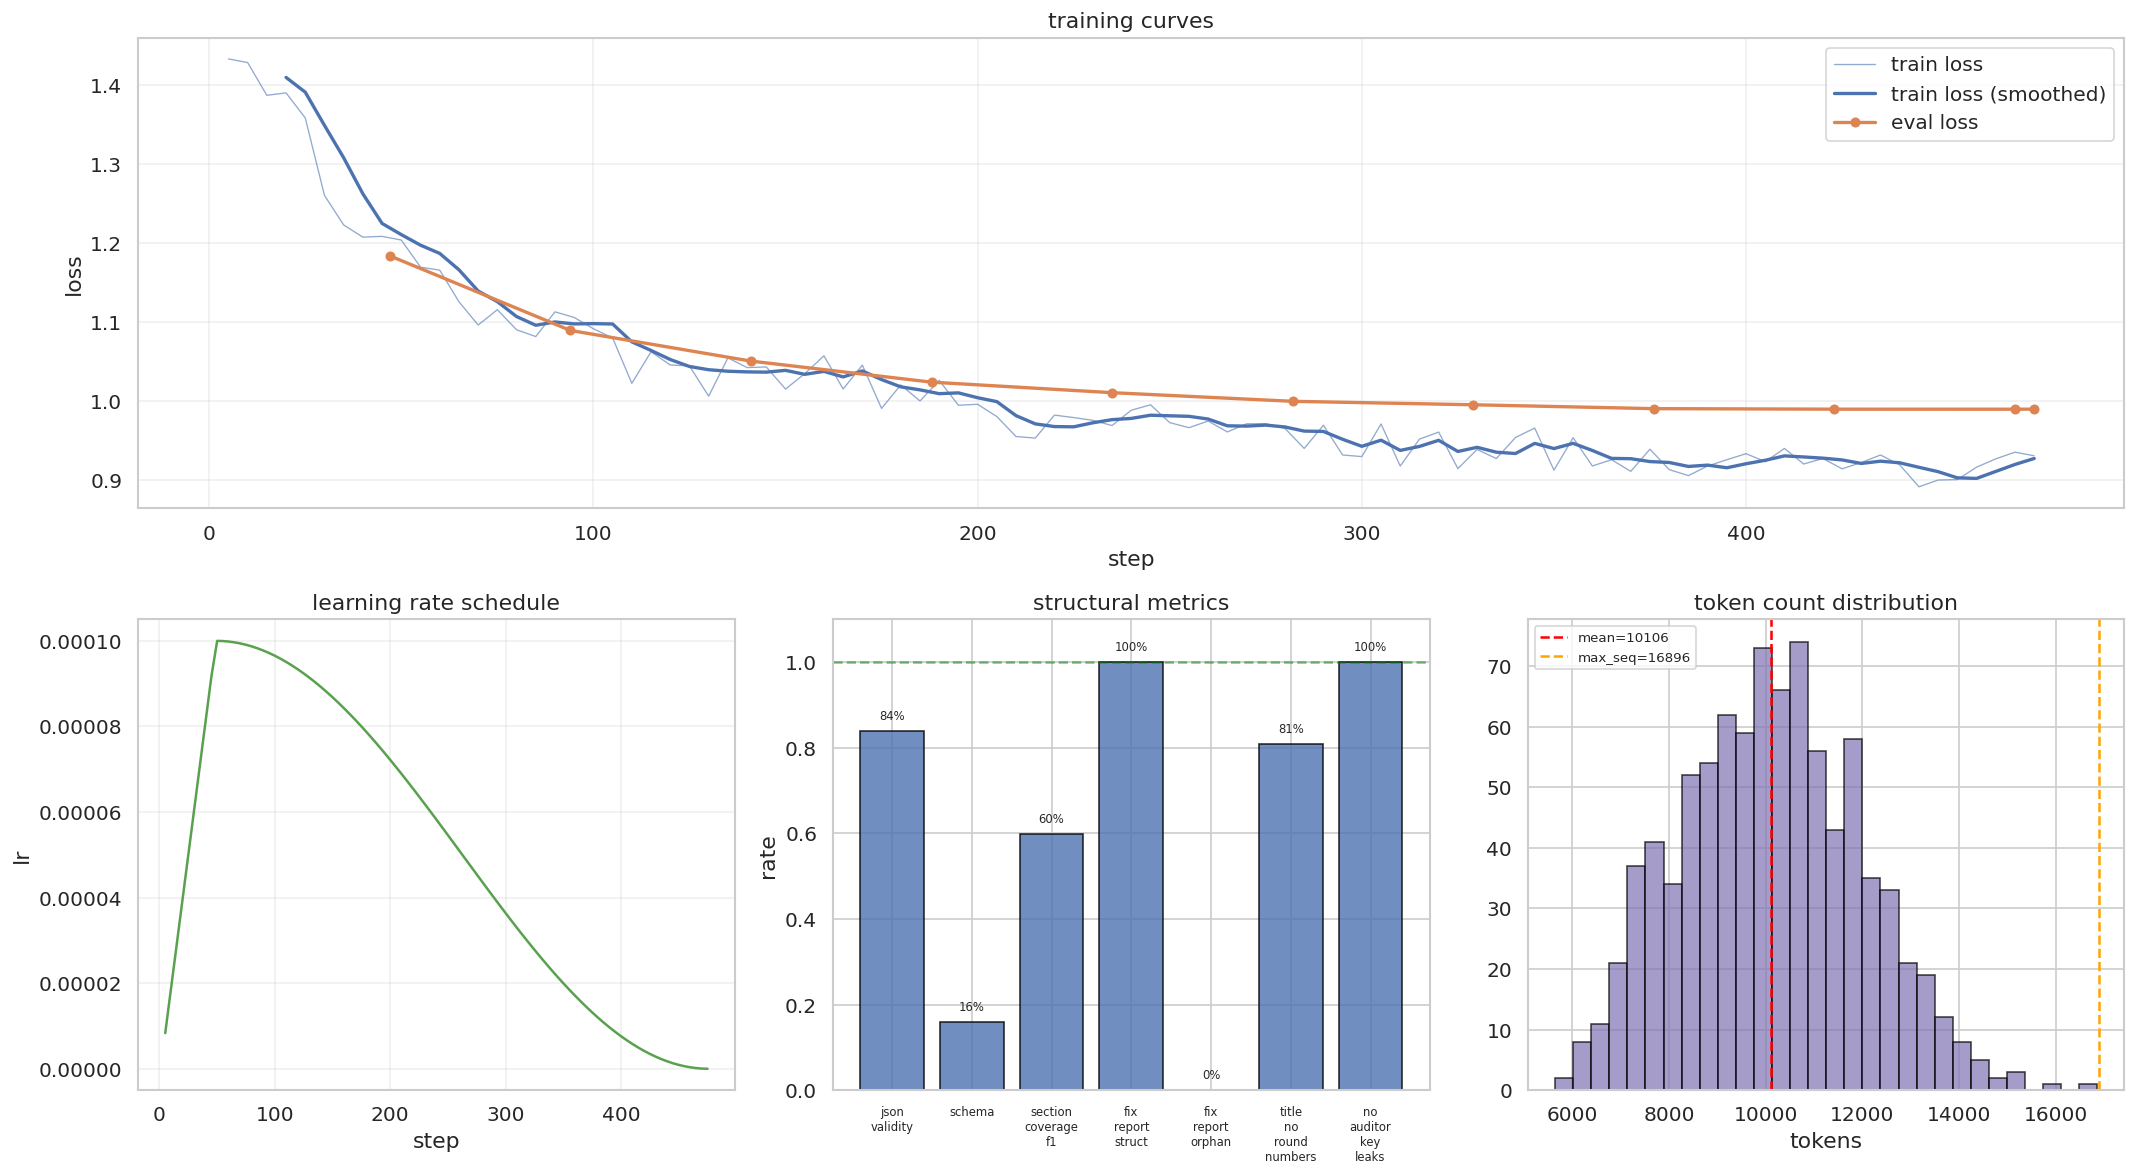

saved: training_output/training_curves.png


In [24]:
if metrics_cb.train_losses and metrics_cb.eval_losses:
    fig = plt.figure(figsize=(18, 10))
    gs = gridspec.GridSpec(2, 3, figure=fig)

    # Training and eval loss curves
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(metrics_cb.steps, metrics_cb.train_losses, alpha=0.6, color='#4C72B0', label='train loss', linewidth=0.8)
    window = max(1, len(metrics_cb.train_losses) // 20)
    if len(metrics_cb.train_losses) >= window:
        smoothed = np.convolve(metrics_cb.train_losses, np.ones(window)/window, mode='valid')
        ax1.plot(metrics_cb.steps[window-1:], smoothed, color='#4C72B0', linewidth=2, label='train loss (smoothed)')
    if metrics_cb.eval_steps_list:
        ax1.plot(metrics_cb.eval_steps_list, metrics_cb.eval_losses, 'o-', color='#DD8452', linewidth=2, markersize=5, label='eval loss')
    ax1.set_xlabel('step')
    ax1.set_ylabel('loss')
    ax1.set_title('training curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # LR schedule
    ax2 = fig.add_subplot(gs[1, 0])
    if metrics_cb.learning_rates:
        ax2.plot(metrics_cb.steps[:len(metrics_cb.learning_rates)], metrics_cb.learning_rates, color='#59A14F', linewidth=1.5)
    ax2.set_title('learning rate schedule')
    ax2.set_xlabel('step')
    ax2.set_ylabel('lr')
    ax2.grid(True, alpha=0.3)

    # Structural metrics bar chart
    ax3 = fig.add_subplot(gs[1, 1])
    metric_names = list(structural.keys())
    metric_vals = [structural[k] for k in metric_names]
    short_names = [k.replace('_rate', '').replace('_compliance', '').replace('_', '\n') for k in metric_names]
    bars = ax3.bar(range(len(metric_names)), metric_vals, color='#4C72B0', edgecolor='black', alpha=0.8)
    ax3.set_xticks(range(len(metric_names)))
    ax3.set_xticklabels(short_names, fontsize=7)
    ax3.set_ylim(0, 1.1)
    ax3.axhline(1.0, color='green', linestyle='--', alpha=0.5)
    ax3.set_title('structural metrics')
    ax3.set_ylabel('rate')
    for bar, val in zip(bars, metric_vals):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.0%}', ha='center', va='bottom', fontsize=7)

    # Token count distribution
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.hist(token_counts, bins=30, color='#8172B3', edgecolor='black', alpha=0.7)
    ax4.axvline(np.mean(token_counts), color='red', linestyle='--', label=f'mean={np.mean(token_counts):.0f}')
    ax4.axvline(CONFIG['max_seq_length'], color='orange', linestyle='--', label=f'max_seq={CONFIG["max_seq_length"]}')
    ax4.set_title('token count distribution')
    ax4.set_xlabel('tokens')
    ax4.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', bbox_inches='tight')
    plt.show()
    print(f'saved: {OUTPUT_DIR / "training_curves.png"}')

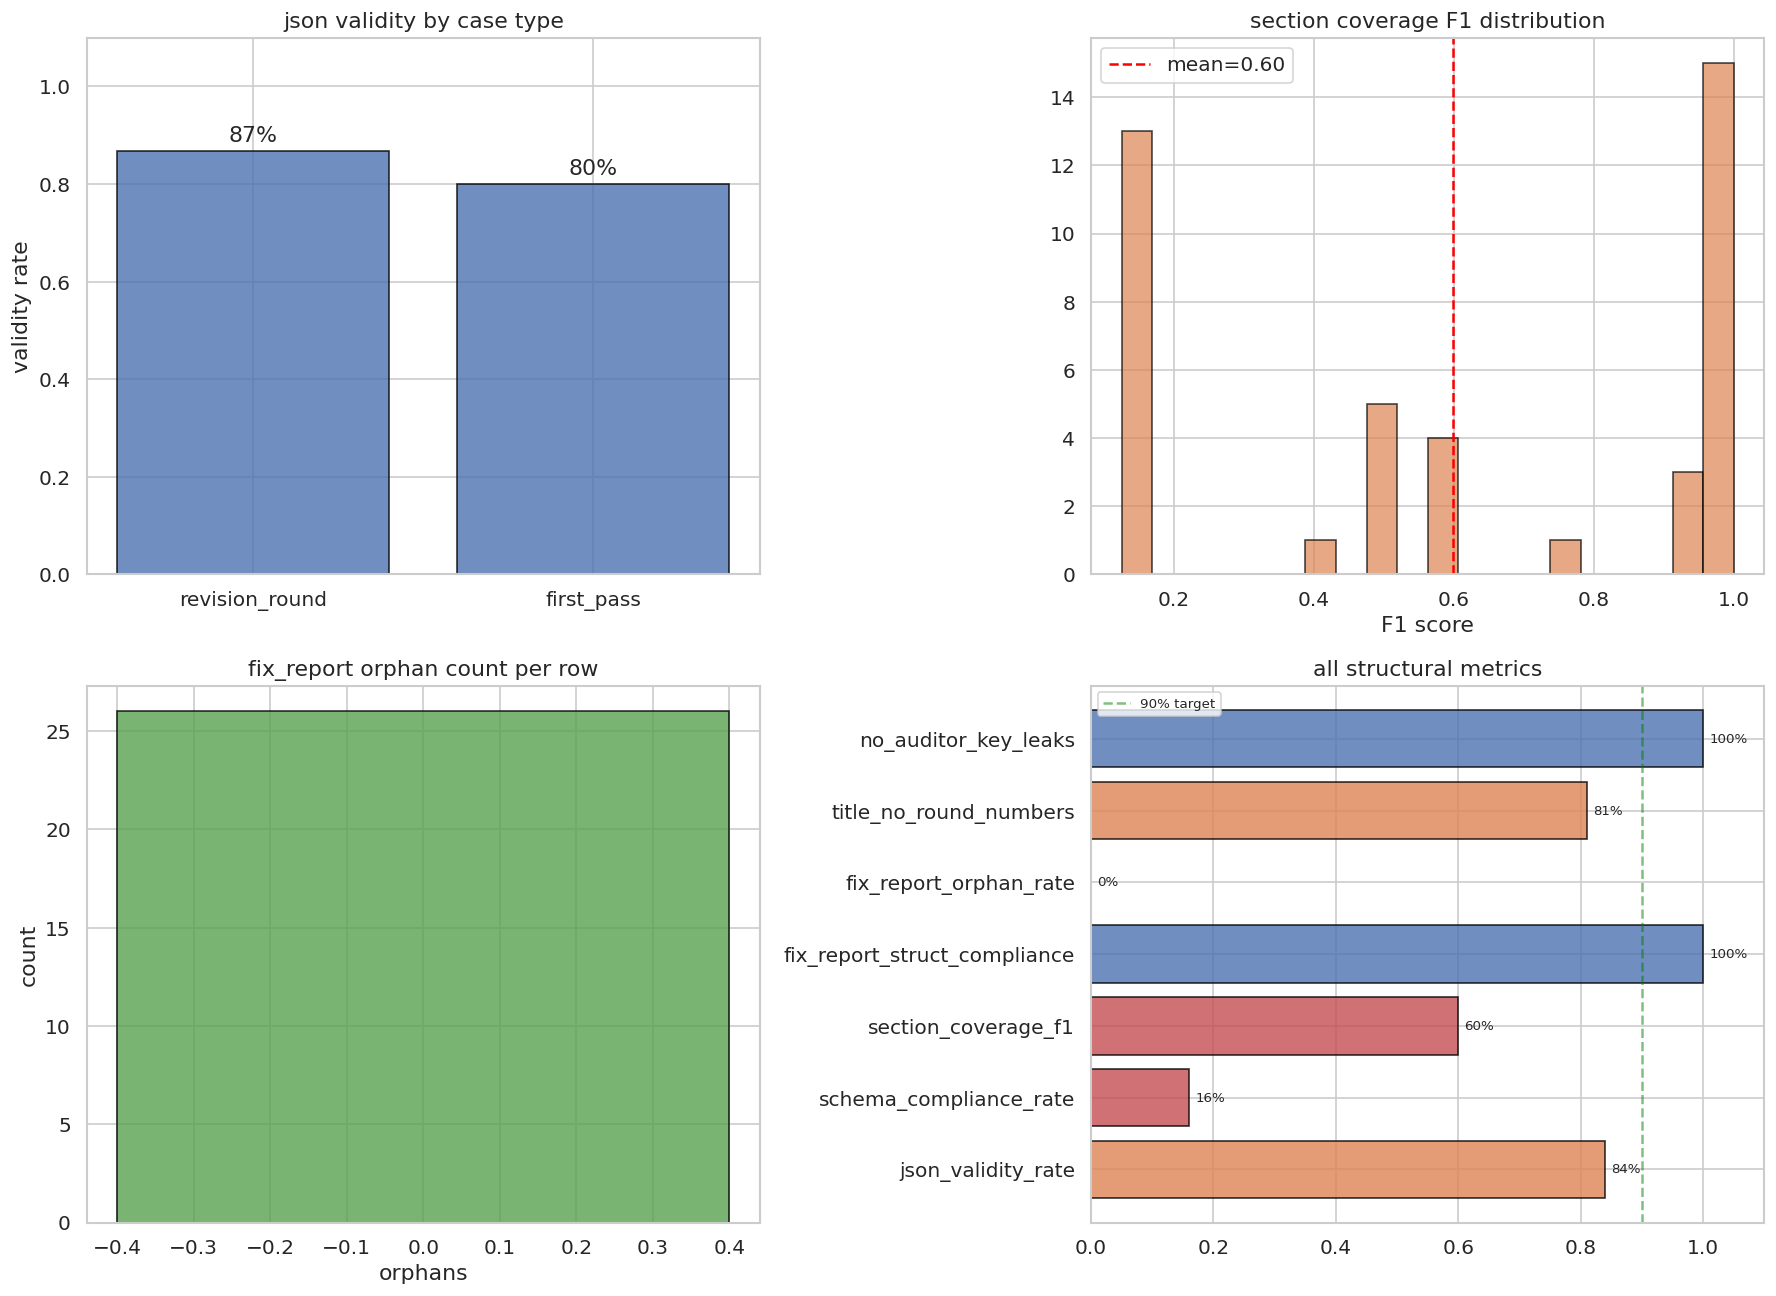

saved: training_output/evaluation_results.png


In [25]:
if predictions:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # JSON validity by case type
    case_type_validity = defaultdict(lambda: {'valid': 0, 'total': 0})
    for p in predictions:
        ct = p.get('case_type', 'unknown')
        case_type_validity[ct]['total'] += 1
        if p['json_valid']:
            case_type_validity[ct]['valid'] += 1
    ct_labels = list(case_type_validity.keys())
    ct_rates = [case_type_validity[k]['valid'] / max(case_type_validity[k]['total'], 1) for k in ct_labels]
    axes[0, 0].bar(ct_labels, ct_rates, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[0, 0].set_ylim(0, 1.1)
    axes[0, 0].set_title('json validity by case type')
    axes[0, 0].set_ylabel('validity rate')
    for x, r in enumerate(ct_rates):
        axes[0, 0].text(x, r + 0.02, f'{r:.0%}', ha='center')

    # Section coverage F1 distribution
    if section_f1s:
        axes[0, 1].hist(section_f1s, bins=20, color='#DD8452', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(np.mean(section_f1s), color='red', linestyle='--', label=f'mean={np.mean(section_f1s):.2f}')
        axes[0, 1].set_title('section coverage F1 distribution')
        axes[0, 1].set_xlabel('F1 score')
        axes[0, 1].legend()

    # fix_report orphan distribution
    if fix_report_orphan_counts:
        orphan_counter = Counter(fix_report_orphan_counts)
        axes[1, 0].bar(orphan_counter.keys(), orphan_counter.values(), color='#59A14F', edgecolor='black', alpha=0.8)
        axes[1, 0].set_title('fix_report orphan count per row')
        axes[1, 0].set_xlabel('orphans')
        axes[1, 0].set_ylabel('count')

    # All structural metrics
    struct_names = list(structural.keys())
    struct_vals = [structural[k] for k in struct_names]
    colors = ['#4C72B0' if v >= 0.9 else '#DD8452' if v >= 0.7 else '#C44E52' for v in struct_vals]
    bars = axes[1, 1].barh(struct_names, struct_vals, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 1].axvline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
    axes[1, 1].set_xlim(0, 1.1)
    axes[1, 1].set_title('all structural metrics')
    axes[1, 1].legend(fontsize=8)
    for bar, val in zip(bars, struct_vals):
        axes[1, 1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.0%}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'evaluation_results.png', bbox_inches='tight')
    plt.show()
    print(f'saved: {OUTPUT_DIR / "evaluation_results.png"}')

---
## Section 13 — Training Record & Summary

In [26]:
record = {
    'agent': 'ArchitectAgent',
    'base_model': MODEL_NAME,
    'dataset_path': DATASET_PATH,
    'dataset_size': len(raw_data),
    'train_rows': len(train_texts),
    'val_rows': len(val_texts),
    'token_stats': {
        'mean': float(np.mean(token_counts)),
        'median': float(np.median(token_counts)),
        'max': int(max(token_counts)),
    },
    'config': CONFIG,
    'trainable_parameters': trainable,
    'trainable_percentage': pct,
    'training_loss': train_result.training_loss,
    'eval_loss': eval_loss,
    'perplexity': perplexity,
    'training_duration_minutes': elapsed / 60,
    'structural_metrics': structural,
    'completion_only_masking': True,
    'chain_aware_split': True,
    'seed': SEED,
}

with open(FINAL_MODEL_DIR / 'training_record.json', 'w') as f:
    json.dump(record, f, indent=2, default=str)

print(f'training record saved: {FINAL_MODEL_DIR / "training_record.json"}')
print(f'\n{"="*60}')
print('ALL OUTPUTS:')
print(f'  adapter:      {FINAL_MODEL_DIR / "lora_adapter"}')
if SAVE_MERGED:
    print(f'  merged model: {FINAL_MODEL_DIR / "merged_model"}')
print(f'  curves:       {OUTPUT_DIR / "training_curves.png"}')
print(f'  evaluation:   {OUTPUT_DIR / "evaluation_results.png"}')
print(f'  metrics:      {OUTPUT_DIR / "all_metrics.json"}')
print(f'  record:       {FINAL_MODEL_DIR / "training_record.json"}')
print(f'  tensorboard:  {LOGS_DIR}')
print(f'{"="*60}')

training record saved: training_output/architect_agent_model/training_record.json

ALL OUTPUTS:
  adapter:      training_output/architect_agent_model/lora_adapter
  merged model: training_output/architect_agent_model/merged_model
  curves:       training_output/training_curves.png
  evaluation:   training_output/evaluation_results.png
  metrics:      training_output/all_metrics.json
  record:       training_output/architect_agent_model/training_record.json
  tensorboard:  training_output/logs


In [27]:
import shutil
shutil.make_archive('/workspace/training_output', 'zip', '/workspace/training_output')

'/workspace/training_output.zip'

---
## Summary

Fine-tuned Phi-3-mini-128k-instruct using QLoRA with completion-only loss masking
to serve as the ArchitectAgent in the governance multi-agent system.

### How to load for inference

```python
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# Option A: LoRA adapter (smaller, needs base model loaded separately)
base = AutoModelForCausalLM.from_pretrained('microsoft/Phi-3-mini-128k-instruct')
model = PeftModel.from_pretrained(base, 'training_output/architect_agent_model/lora_adapter')

# Option B: Merged standalone model
model = AutoModelForCausalLM.from_pretrained('training_output/architect_agent_model/merged_model')
```